In [62]:
import pyrpl
from pyrpl import Pyrpl
from datetime import datetime
from time import sleep
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis
import types
import matplotlib.animation as animation
import matplotlib
import scipy

plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 400

"""
font = {'family': 'DejaVu Sans', 'weight': 'regular', 'size': 14}
plt.rc('font', **font)
"""


finesse.init_plotting()


HOSTNAME = "192.168.0.157"
PASSWORD = "ligobears"

p = Pyrpl(config='', hostname=HOSTNAME, password=PASSWORD, gui=False)
rp = p.rp






INFO:pyrpl.redpitaya:Correct FPGA image detected, skipping reload
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname 192.168.0.157.


In [63]:
c = 299792458
red_wavelength = 1064e-9
red_frequency = c / red_wavelength
green_wavelength = 532e-9
green_frequency = c / green_wavelength

n_crystal_red = 1.8302 #index of KTP crystal at 1064 nm
n_crystal_green = 1.8894 #index of KTP crystal at 532 nm



In [64]:
tunable_fc_params = dict(
    laser_power = 1, #532 nm laser power in watts
    L0 = 20e-2 + 0*0.075189 * red_wavelength,
    L = 0,
    t1 = 0.1,
    t2 = 0.001,
    modulation_freq = 10e6,
    sideband_depth = 1.08
)

params = types.SimpleNamespace(tunable_fc_params)
params.L = params.L0



In [65]:
def analyze_spectrum(input1: str, span: float = 1e6, window='blackman'):
    p.spectrumanalyzer.setup(input1_baseband=input1, input2_baseband='off', baseband=True, span=span, window=window)

    ch1, ch2, cross_re, cross_im = p.spectrumanalyzer.single()

    return p.spectrumanalyzer.frequencies, ch1



In [66]:
power2volts = 0.25

def transfer_function(omega, cavity_length):
    t1 = params.t1
    t2 = params.t2
    r1 = np.sqrt(1 - t1**2)
    r2 = np.sqrt(1 - t2**2)
    alpha = omega * cavity_length / c

    numerator = -r1 + (r1**2 + t1**2)*r2*np.exp(2j * alpha)
    denominator = 1 - r1 * r2 * np.exp(2j * alpha)
    return numerator / denominator 

def reflected_field(t, E0, L, omega, omega_m, beta):
    carrier_field = E0 * transfer_function(omega, L) * np.exp(1j * omega * t)

    sideband_field = (beta/2) * E0 * (transfer_function(omega+omega_m, L) * np.exp(1j * (omega + omega_m) * t) - transfer_function(omega-omega_m, L) * np.exp(1j * (omega - omega_m) * t))

    return carrier_field + sideband_field


def reflected_power(t, P0, cavity_length, f, sideband_f, beta):
    return np.abs(reflected_field(t, np.sqrt(P0), cavity_length, 2*np.pi*f, 2*np.pi*sideband_f, beta))**2


waveform_x = np.linspace(0, 1 / params.modulation_freq, num=16384)

waveform_y = power2volts * reflected_power(waveform_x, params.laser_power, params.L, red_frequency, params.modulation_freq, params.sideband_depth)


#plt.plot(waveform_y)




In [67]:
def reset():
    rp.asg0.output_direct = 'off'
    rp.asg1.output_direct = 'off'
    rp.iq0.output_direct = 'off'
    rp.iq0.output_signal = 'off'


reset()

In [68]:
asg = rp.asg0
asg.output_direct = 'out1'

#asg.setup(waveform='sin', frequency=100, amplitude=0.5, trigger_source='immediately', offset=0)

#asg.setup()
#asg.waveform = 'sin'

#asg.trigger_source = 'immediately' #Seems to overwrite the custom waveform data, but if I don't have it then ASG doesn't activate consistently?

asg.data = waveform_y

asg.frequency = params.modulation_freq
asg.amplitude = 0.5
asg.offset = 0



In [83]:
iq = rp.iq0

iq.setup(frequency=params.modulation_freq,
         bandwidth = [10e3,20e3], #Low pass filter
         acbandwidth = 50000, #High pass filter
         gain = 0.0,
         phase = 0,
         amplitude = 1,
         input = 'in1',
         output_direct = 'out2',
         output_signal = 'quadrature',
         quadrature_factor = 3)

iq.bandwidth = params.modulation_freq * np.array([1, 1]) * 1e-5 #Low pass filter
iq.acbandwidth = params.modulation_freq * 1



In [70]:
def distance_from_stability(L):
    return ((((L / red_wavelength) + 0.5) % 1) - 0.5)

def scanPiezo(output_direct: str = 'out2', frequency: float = 1e0, amp: float = 0.5, offset:float = 0.5):
    reset()
    rp.asg1.setup(waveform = 'halframp', output_direct=output_direct, frequency=frequency, amplitude=amp, offset=offset, trigger_source = 'immediately')
    

def sweep(start: float, end: float, number: int, sleep_time, randomize_sample_order=False):
    asg.data = np.zeros(16384)
    
    #fig1, ax1 = plt.subplots(1)
    lengths = np.linspace(start, end, number)
    errors = np.zeros(number)
    
    if(randomize_sample_order == True): np.random.shuffle(lengths)
    

    for i in range(number):
        waveform_data = power2volts * reflected_power(waveform_x, params.laser_power, lengths[i], red_frequency, params.modulation_freq, params.sideband_depth)
        asg.data = waveform_data
        
        sleep(sleep_time)
        errors[i] = iq.current_output_signal.real


        #rp.hk.led = (1 << min(abs(int(errors[i] * 70)), 8) % 9) - 1
        #ax1.plot(waveform_data, alpha=0.1)
        
    rp.hk.led = 0b11111111
    sleep(0.25)
    rp.hk.led = 0b00000000


    return lengths, errors
    
    

In [71]:

num_divisions = 100
power_proportions = np.zeros(num_divisions)
LO_amplitudes = np.linspace(0.95, 1.05, num_divisions)

sleep_time = 0.0001

#np.random.shuffle(LO_amplitudes)

for i in range(num_divisions):
    iq.amplitude = LO_amplitudes[i]

    sleep(sleep_time)

    LO_spectrum_freqs, LO_spectrum_powers = analyze_spectrum(input1='out2', span=100e6)

    sleep(sleep_time)

    modulation_freq_index = np.argmin(np.abs(LO_spectrum_freqs - params.modulation_freq))
    frequency_spacing = (np.max(LO_spectrum_freqs) - np.min(LO_spectrum_freqs)) / len(LO_spectrum_freqs)

    lower_bound_freq = 0.95 * params.modulation_freq
    upper_bound_freq = 1.05 * params.modulation_freq

    lower_bound_index = int(lower_bound_freq / frequency_spacing)
    upper_bound_index = int(upper_bound_freq / frequency_spacing)

    peak_indices, __ = scipy.signal.find_peaks(LO_spectrum_powers, threshold=1e-100, prominence=1e-10, distance=100)

    total_spectrum_power = scipy.integrate.simpson(LO_spectrum_powers, LO_spectrum_freqs)

    modulation_spectrum_power = scipy.integrate.simpson(LO_spectrum_powers[lower_bound_index:upper_bound_index], LO_spectrum_freqs[lower_bound_index:upper_bound_index])

    power_proportions[i] = 100 * modulation_spectrum_power / total_spectrum_power


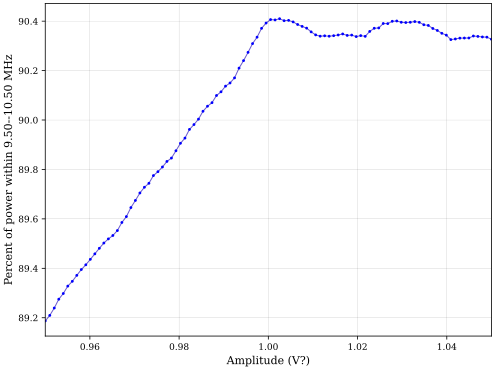

In [78]:
spectrum_fig, spectrum_ax = plt.subplots(1, figsize=(8,6))

spectrum_ax.plot(LO_amplitudes, power_proportions, linewidth=1, color='slateblue', zorder=-1)

spectrum_ax.scatter(LO_amplitudes, power_proportions, s=8, edgecolors='none', color='blue')


spectrum_ax.set_xlabel("Amplitude (V?)")
spectrum_ax.set_ylabel(f"Percent of power within {lower_bound_freq*1e-6:0.2f}--{upper_bound_freq*1e-6:0.2f} MHz")

#spectrum_ax.plot(LO_spectrum_freqs, LO_spectrum_powers)

spectrum_fig.savefig('LO_spectrum.png')

In [73]:
#scanPiezo(output_direct='out2', frequency=0.1, amp=0.5)



In [74]:
L_vals, error_vals = sweep(params.L0 + red_wavelength * 0.060, params.L0 + red_wavelength * 0.090, 100, sleep_time=0.000, randomize_sample_order=False)


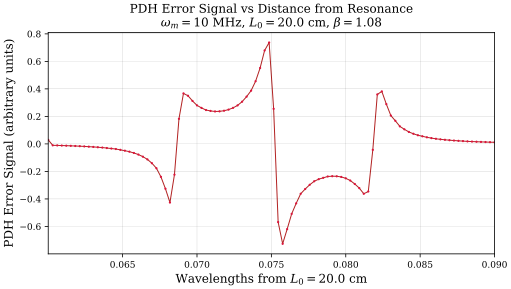

In [75]:
error_fig, error_ax = plt.subplots(1, figsize=(8, 4))


min_idx = np.argmin(np.abs(error_vals))

error_ax.scatter((L_vals - params.L0) / red_wavelength, error_vals, color='crimson', s=5, alpha=1, edgecolors='none')

error_ax.plot((L_vals - params.L0) / red_wavelength, error_vals, color='firebrick', linewidth=1, zorder=-1)

#ax2.scatter((L_vals[min_idx] - params.L0) / red_wavelength, error_vals[min_idx], color='blue', s=10)

error_ax.set_xlabel(rf"Wavelengths from $L_0 = {params.L0*1e2}$ cm", fontsize=12)
error_ax.set_ylabel(rf"PDH Error Signal (arbitrary units)", fontsize=12)
error_ax.set_title("PDH Error Signal vs Distance from Resonance\n" rf"$\omega_m = {(params.modulation_freq*1e-6):0.0f}$ MHz, $L_0 = {params.L0*1e2}$ cm, $\beta = {params.sideband_depth}$")

error_fig.savefig("fig.png")

In [76]:

control_pid = rp.pid1
control_pid.input = 'iq0'
control_pid.ival = 0 #Reset integrator to 0


PID_sign = 1

control_pid.p = PID_sign * 0.003
control_pid.i = PID_sign * 0.0004

times = []
dists_from_lock = []

volts_to_servo_distance = red_wavelength

pid0 = rp.pid0

pid0.input = 'pid1'
pid0.p = 1.0
pid0.i = 0.0

pid0.output_direct = 'out2'

#i = 0

while(False):
    params.L = params.L0 + volts_to_servo_distance * control_pid.current_output_signal
    waveform_data = power2volts * reflected_power(waveform_x, params.laser_power, params.L, red_frequency, params.modulation_freq, params.sideband_depth)
    asg.data = waveform_data

    print(f"PID Value: {control_pid.current_output_signal*1e3: f}  |   Dist from resonance: {distance_from_stability(params.L)*1e3: f}")
    
    #i = (i + 1) % 5
    #if(i != 1000): print('\r')
    sleep(0.05)




In [77]:


"""

for i in range(100):
    #print(control_pid.ival)
    params.L = params.L0 + volts_to_servo_distance * control_pid.current_output_signal#* np.sin(i / (4 * np.pi))
    waveform_data = power2volts * reflected_power(waveform_x, params.laser_power, params.L, red_frequency, params.modulation_freq, params.sideband_depth)
    asg.data = waveform_data

    sleep(0.05)

    times.append(datetime.now().strftime("%M:%S.%f"))
    dists_from_lock.append(distance_from_stability(params.L))



pid_fig, pid_ax = plt.subplots(1)

pid_ax.scatter(times, dists_from_lock, color='purple', s=4, edgecolors='none')

pid_ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(6))

#pid_ax.set_xlabel(rf"Wavelengths from $L_0 = {params.L*1e2}$ cm", fontsize=10)
#pid_ax.set_ylabel(rf"PDH Error Signal (arbitrary units)", fontsize=10)
"""

"""
def animate_pid_plot(i, xdata, ydata):
    print("test")
    #xdata.append(datetime.now().strftime("%M:%S.%f"))
    #ydata.append(control_pid.current_output_signal)

    #xdata = xdata[-20:]
    #ydata = ydata[-20:]

    #pid_ax.clear()
    #pid_ax.plot(xdata, ydata)



ani = animation.FuncAnimation(pid_figure, animate_pid_plot, fargs=(times, dists_from_lock), frames=20, interval=2)
"""

'\ndef animate_pid_plot(i, xdata, ydata):\n    print("test")\n    #xdata.append(datetime.now().strftime("%M:%S.%f"))\n    #ydata.append(control_pid.current_output_signal)\n\n    #xdata = xdata[-20:]\n    #ydata = ydata[-20:]\n\n    #pid_ax.clear()\n    #pid_ax.plot(xdata, ydata)\n\n\n\nani = animation.FuncAnimation(pid_figure, animate_pid_plot, fargs=(times, dists_from_lock), frames=20, interval=2)\n'